In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pyhepmc as hp
from particle import Particle

In [3]:
filename = "../CollisionSimulation/electron_proton.hepmc"

In [4]:
with hp.open(filename) as f:
    event = f.read()

event

<GenEvent momentum_unit=1, length_unit=0, event_number=0, particles=76, vertices=46, run_info=GenRunInfo(tools=[], weight_names=['Weight'], attributes={})>

In [5]:
particleEnergies = {}
pseudorapidities = []

numFinalStateParticles = 0

with hp.open(filename) as f:
    for event in f:
        print(f"Event number: {event.event_number}")
        print(f"Number of particles: {len(event.particles)}")
        for particle in event.particles:
            # Add particle name and energy to particleEnergies if it's a final state particle
            if particle.status == 1:
                numFinalStateParticles += 1
                name = Particle.from_pdgid(particle.pid).latex_name
                energy = particle.momentum.e
                if name not in particleEnergies:
                    particleEnergies[name] = []
                particleEnergies[name].append(energy)
                pseudorapidities.append(particle.momentum.eta())
                
print(f"Total number of final state particles: {numFinalStateParticles}")

Event number: 0
Number of particles: 76
Event number: 1
Number of particles: 37
Event number: 2
Number of particles: 48
Event number: 3
Number of particles: 144
Event number: 4
Number of particles: 60
Event number: 5
Number of particles: 59
Event number: 6
Number of particles: 86
Event number: 7
Number of particles: 51
Event number: 8
Number of particles: 45
Event number: 9
Number of particles: 38
Event number: 10
Number of particles: 67
Event number: 11
Number of particles: 30
Event number: 12
Number of particles: 77
Event number: 13
Number of particles: 122
Event number: 14
Number of particles: 57
Event number: 15
Number of particles: 55
Event number: 16
Number of particles: 51
Event number: 17
Number of particles: 61
Event number: 18
Number of particles: 61
Event number: 19
Number of particles: 47
Event number: 20
Number of particles: 38
Event number: 21
Number of particles: 56
Event number: 22
Number of particles: 74
Event number: 23
Number of particles: 56
Event number: 24
Number 

In [6]:
particleCounts = {particle: len(energies) for particle, energies in particleEnergies.items()}
total = sum(particleCounts.values())
particlePercentageValues = {k: (v / total) * 100 for k, v in particleCounts.items()}

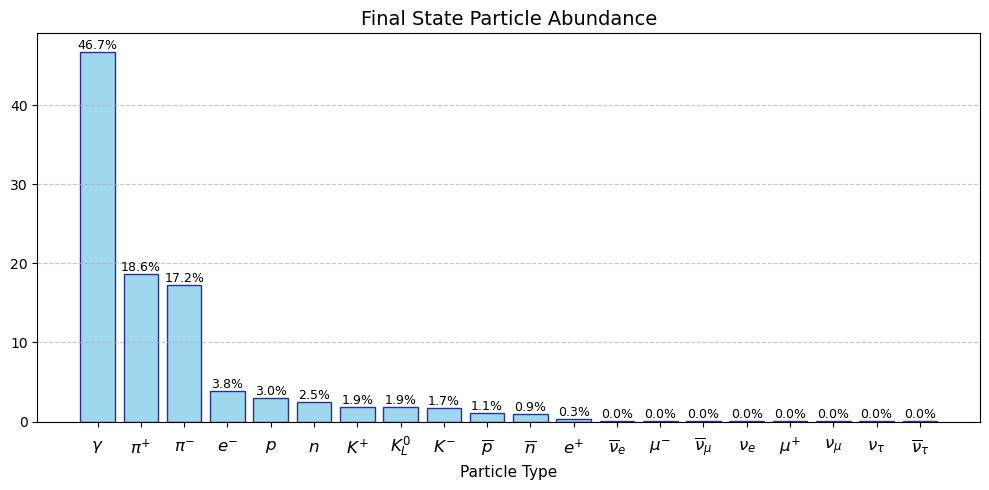

In [7]:
sorted_data = dict(sorted(particlePercentageValues.items(), key=lambda item: item[1], reverse=True))

names = list(sorted_data.keys())
counts = list(sorted_data.values())

plt.figure(figsize=(10, 5))
bars = plt.bar(names, counts, color='skyblue', edgecolor='navy', alpha=0.8)

plt.xticks([i for i in range(len(names))], [f"${n}$" for n in names], fontsize=12, va="center")

plt.tick_params(axis='x', which='major', pad=15)
plt.xlabel('Particle Type', fontsize=11)
plt.title('Final State Particle Abundance', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7, which='both')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f"{yval:.1f}%", va='bottom', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [8]:
sorted(particleEnergies["\\pi^{+}"])[-10:]

[160.40251737807378,
 160.53969303330004,
 161.11477411910528,
 162.508895147611,
 163.85833969244214,
 165.9393874456718,
 179.33651387360666,
 182.7904004400972,
 207.64183349165313,
 213.37979151475966]

(array([1.349e+03, 8.340e+02, 5.030e+02, 3.460e+02, 2.410e+02, 2.220e+02,
        1.730e+02, 1.260e+02, 9.900e+01, 9.500e+01, 7.800e+01, 8.800e+01,
        8.400e+01, 5.600e+01, 4.500e+01, 4.700e+01, 4.700e+01, 5.000e+01,
        4.600e+01, 3.900e+01, 2.400e+01, 2.400e+01, 2.800e+01, 2.700e+01,
        1.800e+01, 2.000e+01, 3.200e+01, 2.500e+01, 1.700e+01, 1.600e+01,
        2.100e+01, 1.700e+01, 1.300e+01, 1.600e+01, 1.500e+01, 7.000e+00,
        1.500e+01, 1.100e+01, 1.600e+01, 9.000e+00, 9.000e+00, 1.200e+01,
        1.500e+01, 8.000e+00, 1.200e+01, 5.000e+00, 1.200e+01, 7.000e+00,
        1.200e+01, 1.300e+01, 8.000e+00, 8.000e+00, 3.000e+00, 7.000e+00,
        1.100e+01, 1.000e+01, 3.000e+00, 1.400e+01, 5.000e+00, 9.000e+00,
        6.000e+00, 1.000e+00, 4.000e+00, 7.000e+00, 2.000e+00, 4.000e+00,
        6.000e+00, 8.000e+00, 2.000e+00, 4.000e+00, 4.000e+00, 1.000e+00,
        7.000e+00, 2.000e+00, 3.000e+00, 3.000e+00, 0.000e+00, 5.000e+00,
        1.000e+00, 1.000e+00, 1.000e+0

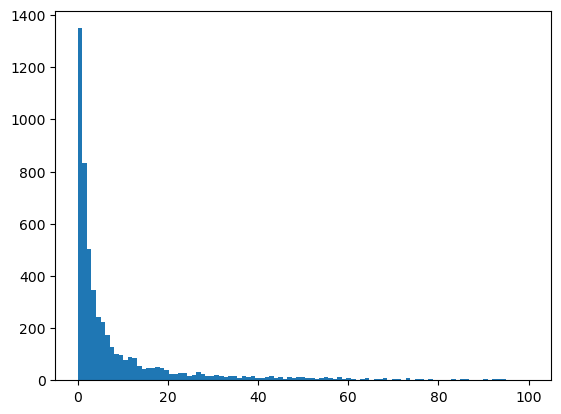

In [14]:
plt.hist(particleEnergies["\\pi^{+}"], bins=np.linspace(0, 100, 100))


In [10]:
pseudorapidities

[1.1835070969836163,
 1.398536432643694,
 3.8478242200273716,
 3.095253847638954,
 5.6247721551853775,
 -0.3200426555255498,
 -0.2845113180334227,
 1.6385073840903535,
 1.2391992511746408,
 3.439709460009745,
 6.6806804505718524,
 5.796999821295338,
 -1.09301937926828,
 0.9213695049476852,
 0.6134856139594898,
 2.942620230402551,
 1.3496862209205684,
 1.4086452680570118,
 0.6652819694369051,
 0.7830858061747473,
 0.5066715980063105,
 1.4324962177465224,
 0.5594785814790323,
 0.929885101133454,
 0.8155908265373716,
 2.4844266211181694,
 2.79484849377435,
 2.0503165886001966,
 3.1137430471291436,
 6.566938356254873,
 5.312718308665906,
 0.5750219444687453,
 2.1008414610360098,
 2.0565862145234886,
 -0.5683651068757649,
 2.02834101744042,
 1.8296196967801597,
 1.5479870541892815,
 2.1165499661470952,
 2.529869967452332,
 4.0648151100801675,
 7.1310567456610885,
 1.1178466573440877,
 1.4042403686488538,
 1.5783428110844528,
 1.6080764757255686,
 1.3054936835562752,
 1.9032879161060545,
 1.

(array([1.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 4.000e+00, 5.000e+00,
        5.000e+00, 2.100e+01, 3.600e+01, 5.700e+01, 9.300e+01, 1.620e+02,
        2.330e+02, 6.360e+02, 8.530e+02, 1.058e+03, 1.096e+03, 1.259e+03,
        1.334e+03, 1.399e+03, 1.387e+03, 1.383e+03, 1.559e+03, 1.501e+03,
        1.485e+03, 1.344e+03, 1.271e+03, 1.130e+03, 1.013e+03, 1.031e+03,
        9.780e+02, 9.340e+02, 9.550e+02, 8.880e+02, 8.700e+02, 7.780e+02,
        6.010e+02, 4.260e+02, 2.990e+02, 1.660e+02, 9.000e+01, 6.600e+01,
        3.500e+01, 1.500e+01, 6.000e+00, 1.000e+00, 1.000e+00, 3.000e+00,
        2.000e+00, 2.000e+00]),
 array([-5.27875444, -4.97667798, -4.67460151, -4.37252505, -4.07044858,
        -3.76837212, -3.46629565, -3.16421919, -2.86214272, -2.56006626,
        -2.2579898 , -1.95591333, -1.65383687, -1.3517604 , -1.04968394,
        -0.74760747, -0.44553101, -0.14345454,  0.15862192,  0.46069839,
         0.76277485,  1.06485132,  1.36692778,  1.66900425,  1.97108071,
         2.

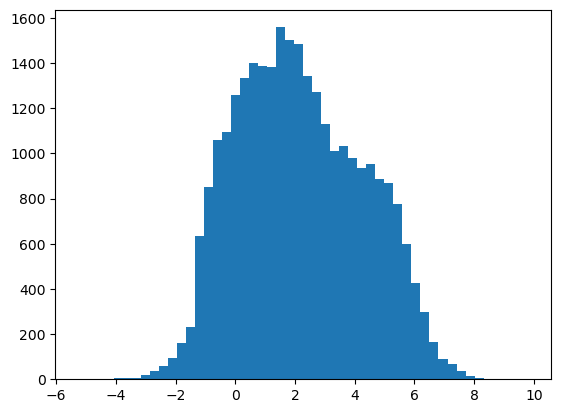

In [11]:
plt.hist(pseudorapidities, bins=50)